# Validación del Módulo Predictivo — Datos de BD (Pipeline)

Este notebook **no ejecuta ningún cálculo VPM**. Solo LEE los resultados ya
persistidos por el pipeline en `predicciones_ventana` y los compara contra
el rendimiento del pipeline (`produccion_acumulada_ciclo.rendimiento`).

**BD:** pruebas (solo lectura). No se escribe nada.

## Correcciones metodológicas aplicadas respecto a la versión anterior

1. **Filtro de duración de ciclo (90–160 días):** en lugar de filtrar por `clasificacion_final`,
   se excluyen los ciclos con duración (EOS − SOS) fuera del rango 90–160 días, como criterio
   más simple para descartar ciclos de vegetación de duración anómala (no-maíz) sin depender
   de la etiqueta de clasificación.
2. **EOS excluido de las métricas de validación predictiva:** la ventana EOS no es una predicción
   independiente — es, por diseño del pipeline, el mismo valor que cierra `rendimiento` en
   `produccion_acumulada_ciclo`. Compararla contra sí misma es tautológico (RMSE=0, R²=1 por
   construcción). Se mantiene únicamente como un *sanity check* aislado (celda 6) para confirmar
   que ambos valores coinciden como se espera, y como punto de anclaje visual en los fan charts,
   pero no se reporta como una ventana de predicción más en la tabla de métricas.
3. **R² corregido:** se reemplaza el cuadrado del coeficiente de correlación de Pearson
   (`corrcoef(...)**2`, insensible al sesgo sistemático) por el coeficiente de determinación
   real (`1 - SS_res/SS_tot`), que sí penaliza el sesgo entre predicho y observado.

Usa las funciones existentes de `utils.queries`.

In [1]:
import sys, warnings
sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.notebook import tqdm

from utils.conexionDB import set_db_path, get_db_path
from utils.queries import cargar_ciclos_historicos, cargar_predicciones_ciclo
from config import GPKG_PRUEBAS_PATH

set_db_path(GPKG_PRUEBAS_PATH)
print("BD:", get_db_path())

2026-07-18 12:32:12.903 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 12:32:12.904 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 12:32:12.905 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 12:32:12.907 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 12:32:12.907 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 12:32:12.908 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 12:32:12.909 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 12:32:12.910 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-

BD: c:\Users\mayno\Desktop\SeminarioInvestigacion\segmentacion_clasificacion_estimacion_maiz_comayagua\notebooks\..\data\pipeline_pruebas.gpkg


## 1. Cargar ciclos históricos con rendimiento, filtrados por duración válida

Se descartan ciclos con duración (EOS − SOS) fuera del rango [90, 160] días, como criterio
simple para excluir ciclos de vegetación de duración anómala (no-maíz) identificados durante
el análisis de segmentación fenológica, sin depender de la etiqueta de clasificación explícita.

In [2]:
DURACION_MIN_DIAS = 90
DURACION_MAX_DIAS = 160

df_ciclos = cargar_ciclos_historicos()
print(f"Total ciclos históricos: {len(df_ciclos)}")

# Filtrar solo los que tienen rendimiento y están finalizados
df_ciclos = df_ciclos.dropna(subset=["rendimiento"]).copy()
df_ciclos = df_ciclos[df_ciclos["estado_ciclo"] == "finalizado"]
print(f"Ciclos finalizados con rendimiento: {len(df_ciclos)}")

# Filtro de duración de ciclo (excluye ciclos anómalos, ej. no-maíz de ciclo largo)
df_ciclos["sos"] = pd.to_datetime(df_ciclos["sos"])
df_ciclos["eos"] = pd.to_datetime(df_ciclos["eos"])
df_ciclos["duracion_dias"] = (df_ciclos["eos"] - df_ciclos["sos"]).dt.days

n_antes = len(df_ciclos)
df_ciclos = df_ciclos[
    (df_ciclos["duracion_dias"] >= DURACION_MIN_DIAS) &
    (df_ciclos["duracion_dias"] <= DURACION_MAX_DIAS)
].copy()
n_despues = len(df_ciclos)

print(f"Ciclos dentro del rango de duración válida [{DURACION_MIN_DIAS}-{DURACION_MAX_DIAS}] días: "
      f"{n_despues} de {n_antes} ({n_despues/n_antes*100:.1f}%)")
print(f"Ciclos excluidos por duración anómala: {n_antes - n_despues}")
display(df_ciclos[["id_ciclo", "id_parcela", "temporada", "sos", "eos", "duracion_dias", "rendimiento"]].head())

2026-07-18 12:32:13.143 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 12:32:13.144 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Total ciclos históricos: 281
Ciclos finalizados con rendimiento: 258
Ciclos dentro del rango de duración válida [90-160] días: 150 de 258 (58.1%)
Ciclos excluidos por duración anómala: 108


,id_ciclo,id_parcela,temporada,sos,eos,duracion_dias,rendimiento
0,2693,14,postrera,2020-03-11,2020-06-12,93,140.441881
3,2791,4,primera,2020-04-24,2020-08-14,112,146.646110
4,2755,2,primera,2020-04-25,2020-08-15,112,155.628728
5,2805,5,primera,2020-04-25,2020-08-14,111,155.007672
6,2779,3,primera,2020-04-27,2020-08-19,114,156.637934


## 2. Cargar predicciones de BD por ciclo

Usa `cargar_predicciones_ciclo(id_ciclo)` de `utils.queries`.

In [3]:
def cargar_todas_predicciones(df_ciclos):
    """Carga predicciones T1/T2/T3/EOS para todos los ciclos."""
    dfs = []
    for _, ciclo in tqdm(df_ciclos.iterrows(), total=len(df_ciclos), desc="Cargando predicciones"):
        cid = int(ciclo["id_ciclo"])
        dfp = cargar_predicciones_ciclo(cid)
        if dfp is not None and not dfp.empty:
            dfp["id_ciclo"] = cid
            dfs.append(dfp)
    if not dfs:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)

df_pred = cargar_todas_predicciones(df_ciclos)
print(f"Predicciones cargadas: {len(df_pred)} filas")
ventanas = sorted(df_pred["ventana"].unique()) if not df_pred.empty else []
print(f"Ventanas disponibles: {ventanas}")
display(df_pred.head(10))

Cargando predicciones:   0%|          | 0/150 [00:00<?, ?it/s]

2026-07-18 12:32:13.202 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-18 12:32:13.204 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 12:32:13.210 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 12:32:13.215 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 12:32:13.220 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 12:32:13.223 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': mi

Predicciones cargadas: 594 filas
Ventanas disponibles: ['EOS', 'T1', 'T2', 'T3']


,id_prediccion,ventana,fecha_ventana,gpp_acumulado,npp_acumulado,rendimiento_estimado_qq_ha,rendimiento_estimado_qq_parcela,score_compuesto,score_pearson,score_magnitud_pendiente,cultivo_predicho,id_ciclo
0,10090,EOS,2020-06-12,1194.461200,597.230600,140.441881,341.595384,NaN,None,None,NaN,2693
1,10087,T1,2020-04-10,1249.573202,624.786601,146.921818,357.356470,21.061967,None,None,Otro,2693
2,10088,T2,2020-05-10,1693.695538,846.847769,199.140657,484.367828,27.909871,None,None,Otro,2693
3,10089,T3,2020-06-09,1403.572863,701.786431,165.028729,401.397727,NaN,None,None,NaN,2693
4,10464,EOS,2020-08-14,1247.228295,623.614147,146.646110,275.463132,NaN,None,None,NaN,2791
5,10461,T1,2020-05-24,1346.691170,673.345585,158.340716,297.430526,13.194121,None,None,Otro,2791
6,10462,T2,2020-06-23,1134.322586,567.161293,133.370927,250.526751,9.274144,None,None,Otro,2791
7,10463,T3,2020-07-23,1452.276850,726.138425,170.755227,320.750204,NaN,None,None,NaN,2791
8,10324,EOS,2020-08-15,1323.625654,661.812827,155.628728,333.225058,NaN,None,None,NaN,2755
9,10321,T1,2020-05-25,1607.055306,803.527653,188.953706,404.578965,0.0,None,None,Otro,2755


## 3. Construir DataFrame de convergencia

Se conserva la columna `yield_eos_qq_ha` únicamente para el sanity check de la sección 4 y
como referencia visual en los fan charts — no se usa en el cálculo de métricas de la sección 6.

In [4]:
def construir_convergencia(df_ciclos, df_pred):
    """Construye DataFrame con yield por ventana vs yield final."""
    rows = []
    for _, ciclo in df_ciclos.iterrows():
        id_ciclo = int(ciclo["id_ciclo"])
        row = {
            "id_ciclo": id_ciclo,
            "id_parcela": int(ciclo["id_parcela"]),
            "temporada": ciclo["temporada"],
            "duracion_dias": ciclo["duracion_dias"],
            "yield_final_qq_ha": float(ciclo["rendimiento"]),
        }
        preds_ciclo = df_pred[df_pred["id_ciclo"] == id_ciclo]
        if preds_ciclo.empty:
            rows.append(row)
            continue
        for v in ["T1", "T2", "T3", "EOS"]:
            p = preds_ciclo[preds_ciclo["ventana"] == v]
            if not p.empty:
                y = float(p["rendimiento_estimado_qq_ha"].iloc[0])
                row[f"yield_{v.lower()}_qq_ha"] = y
                final = row["yield_final_qq_ha"]
                row[f"error_{v.lower()}_qq_ha"] = y - final
                row[f"error_pct_{v.lower()}"] = ((y - final) / final * 100) if final else None
            else:
                row[f"yield_{v.lower()}_qq_ha"] = None
                row[f"error_{v.lower()}_qq_ha"] = None
                row[f"error_pct_{v.lower()}"] = None
        rows.append(row)
    return pd.DataFrame(rows)

df_conv = construir_convergencia(df_ciclos, df_pred)
print(f"Total ciclos: {len(df_conv)}")
completos = df_conv.dropna(subset=["yield_t1_qq_ha", "yield_t2_qq_ha", "yield_t3_qq_ha"])
print(f"Con T1, T2 y T3 disponibles: {len(completos)}")
display(df_conv.head(10))

Total ciclos: 150
Con T1, T2 y T3 disponibles: 133


,id_ciclo,id_parcela,temporada,duracion_dias,yield_final_qq_ha,yield_t1_qq_ha,error_t1_qq_ha,error_pct_t1,yield_t2_qq_ha,error_t2_qq_ha,error_pct_t2,yield_t3_qq_ha,error_t3_qq_ha,error_pct_t3,yield_eos_qq_ha,error_eos_qq_ha,error_pct_eos
0,2693,14,postrera,93,140.441881,146.921818,6.479937,4.613963,199.140657,58.698775,41.795777,165.028729,24.586847,17.506777,140.441881,0.0,0.0
1,2791,4,primera,112,146.646110,158.340716,11.694606,7.974713,133.370927,-13.275182,-9.052529,170.755227,24.109117,16.440339,146.646110,0.0,0.0
2,2755,2,primera,112,155.628728,188.953706,33.324978,21.413128,152.902298,-2.726430,-1.751881,174.955562,19.326834,12.418552,155.628728,0.0,0.0
3,2805,5,primera,111,155.007672,183.253331,28.245660,18.222104,149.847374,-5.160298,-3.329060,175.052417,20.044746,12.931454,155.007672,0.0,0.0
4,2779,3,primera,114,156.637934,178.122303,21.484369,13.715943,156.510504,-0.127430,-0.081353,173.825995,17.188062,10.973116,156.637934,0.0,0.0
5,2705,15,primera,98,100.833998,120.409571,19.575573,19.413664,127.572819,26.738821,26.517664,NaN,NaN,NaN,100.833998,0.0,0.0
6,2847,8,primera,112,143.773076,140.514726,-3.258350,-2.266314,175.242098,31.469022,21.887980,157.099347,13.326272,9.268962,143.773076,0.0,0.0
7,2615,0,primera,134,179.262083,161.373937,-17.888147,-9.978768,147.526838,-31.735245,-17.703267,168.770636,-10.491447,-5.852574,179.262083,0.0,0.0
8,2819,6,primera,101,131.229791,165.074247,33.844456,25.790224,154.795228,23.565438,17.957384,140.412278,9.182487,6.997258,131.229791,0.0,0.0
9,2683,13,primera,103,168.009696,185.583040,17.573344,10.459720,151.757496,-16.252200,-9.673370,185.499145,17.489449,10.409786,168.009696,0.0,0.0


## 4. Sanity check — EOS vs. rendimiento final

Confirma que la ventana EOS coincide (o coincide casi exactamente, salvo redondeo) con el
valor de `rendimiento` persistido en `produccion_acumulada_ciclo`. Este resultado esperado
(diferencia ≈ 0) NO se reporta como evidencia de precisión predictiva — es simplemente una
verificación de integridad de los datos, dado que ambos campos deberían representar la misma
cantidad por diseño del pipeline.

In [5]:
sub_eos = df_conv.dropna(subset=["yield_eos_qq_ha", "yield_final_qq_ha"])
diff_eos = (sub_eos["yield_eos_qq_ha"] - sub_eos["yield_final_qq_ha"]).abs()

print(f"Ciclos con ventana EOS disponible: {len(sub_eos)}")
print(f"Diferencia absoluta EOS vs. rendimiento final — máx: {diff_eos.max():.6f} qq/ha, "
      f"media: {diff_eos.mean():.6f} qq/ha")
if diff_eos.max() < 1e-6:
    print("✅ Confirmado: EOS coincide exactamente con el rendimiento final persistido "
          "(no constituye una predicción independiente — se excluye de las métricas).")
else:
    print("⚠️ Se detectaron diferencias no triviales entre EOS y el rendimiento final. "
          "Revisar antes de asumir que EOS es puramente un valor de cierre.")

Ciclos con ventana EOS disponible: 150
Diferencia absoluta EOS vs. rendimiento final — máx: 0.000000 qq/ha, media: 0.000000 qq/ha
✅ Confirmado: EOS coincide exactamente con el rendimiento final persistido (no constituye una predicción independiente — se excluye de las métricas).


## 5. Scatter T1/T2/T3 vs. rendimiento final

EOS se excluye de este panel por ser tautológico (ver sección 4).

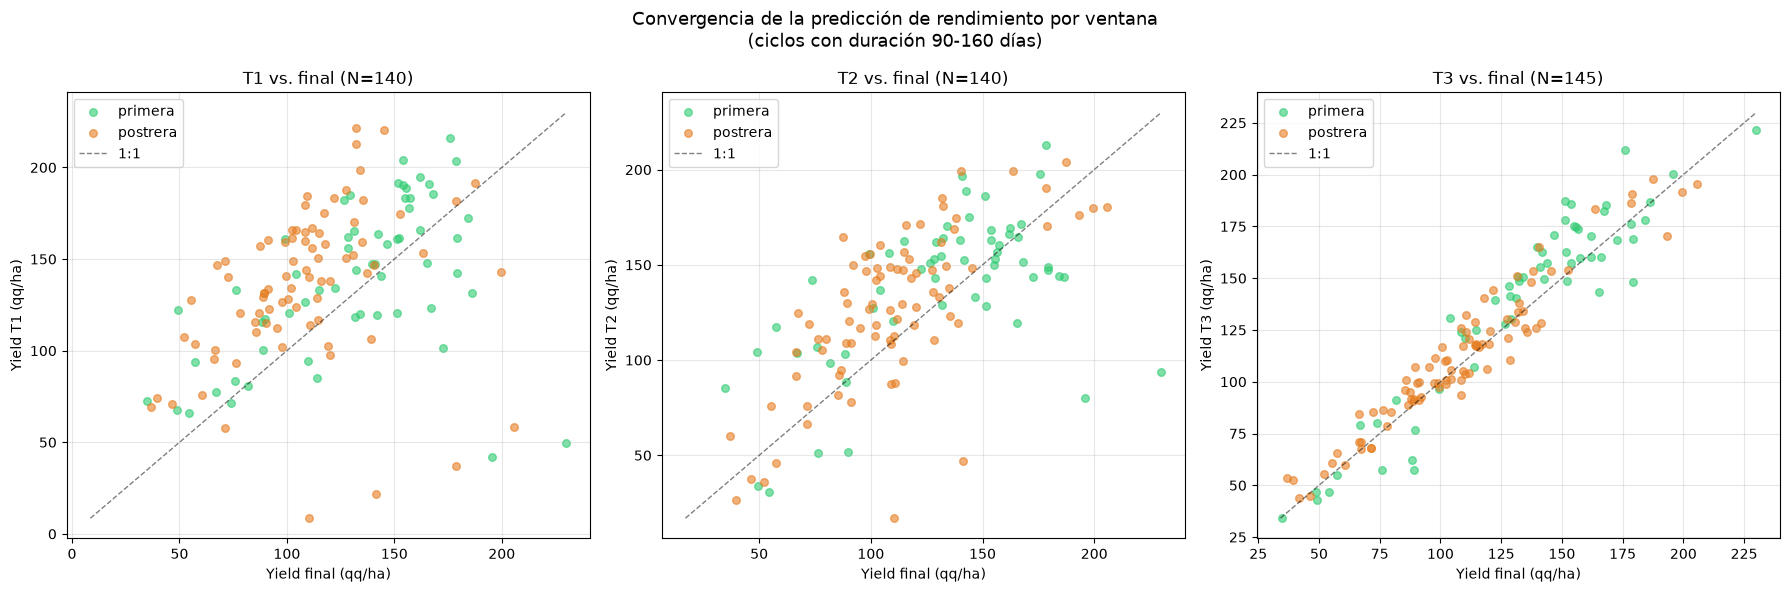

In [6]:
def graficar_scatter_convergencia(df_conv):
    ventanas = ["T1", "T2", "T3"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, v in enumerate(ventanas):
        ax = axes[i]
        col_y = f"yield_{v.lower()}_qq_ha"
        sub = df_conv.dropna(subset=[col_y, "yield_final_qq_ha"])
        if sub.empty:
            ax.set_title(f"{v} - sin datos")
            continue

        for temp, color in [("primera", "#2ecc71"), ("postrera", "#e67e22")]:
            g = sub[sub["temporada"] == temp]
            if not g.empty:
                ax.scatter(g["yield_final_qq_ha"], g[col_y],
                           color=color, alpha=0.6, s=30, label=temp)

        lims = [
            min(sub["yield_final_qq_ha"].min(), sub[col_y].min()),
            max(sub["yield_final_qq_ha"].max(), sub[col_y].max()),
        ]
        ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="1:1")
        ax.set_xlabel("Yield final (qq/ha)")
        ax.set_ylabel(f"Yield {v} (qq/ha)")
        ax.set_title(f"{v} vs. final (N={len(sub)})")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.suptitle("Convergencia de la predicción de rendimiento por ventana\n"
                 f"(ciclos con duración {DURACION_MIN_DIAS}-{DURACION_MAX_DIAS} días)", fontsize=13)
    plt.tight_layout()
    plt.savefig("scatter_convergencia_rendimiento_db.pdf", format="pdf", bbox_inches="tight")
    plt.show()

graficar_scatter_convergencia(df_conv)

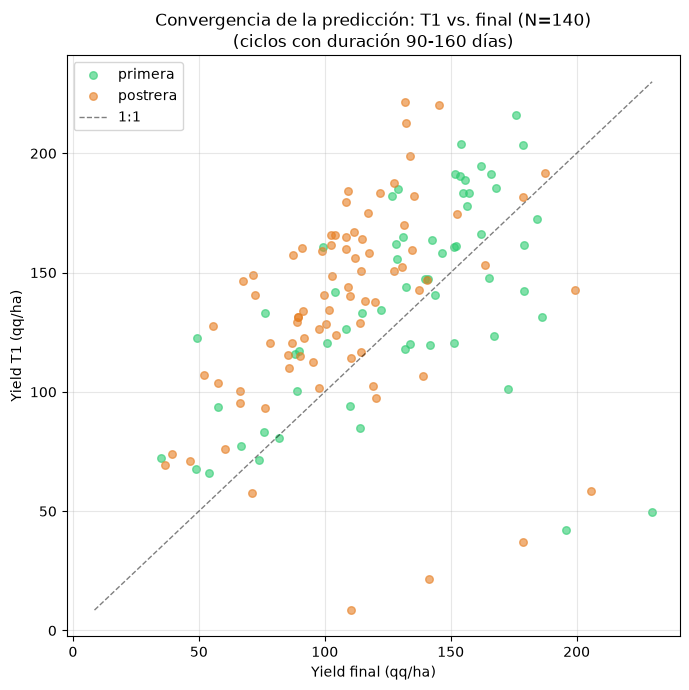

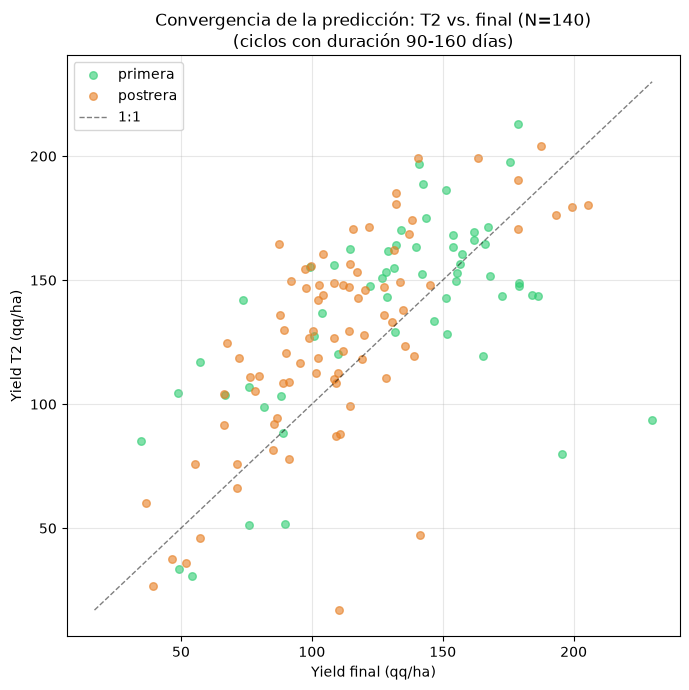

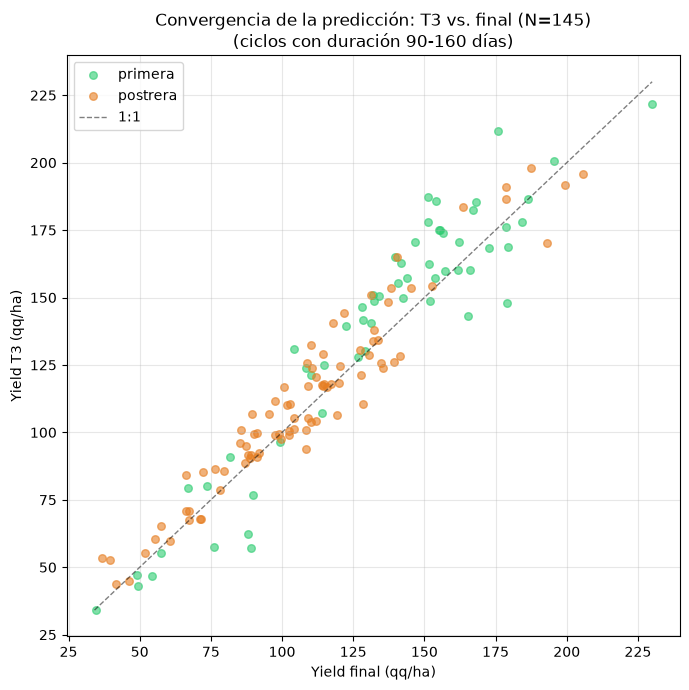

In [12]:
import matplotlib.pyplot as plt

def graficar_scatter_convergencia(df_conv):
    ventanas = ["T1", "T2", "T3"]

    for v in ventanas:
        # Crear una nueva figura independiente para cada ventana
        fig, ax = plt.subplots(figsize=(7, 7))

        col_y = f"yield_{v.lower()}_qq_ha"
        sub = df_conv.dropna(subset=[col_y, "yield_final_qq_ha"])
        
        if sub.empty:
            ax.set_title(f"{v} - sin datos")
        else:
            # Graficar puntos por temporada
            for temp, color in [("primera", "#2ecc71"), ("postrera", "#e67e22")]:
                g = sub[sub["temporada"] == temp]
                if not g.empty:
                    ax.scatter(g["yield_final_qq_ha"], g[col_y],
                               color=color, alpha=0.6, s=30, label=temp)

            # Calcular y graficar línea 1:1
            lims = [
                min(sub["yield_final_qq_ha"].min(), sub[col_y].min()),
                max(sub["yield_final_qq_ha"].max(), sub[col_y].max()),
            ]
            ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="1:1")

            # Configuración de la gráfica
            ax.set_xlabel("Yield final (qq/ha)")
            ax.set_ylabel(f"Yield {v} (qq/ha)")
            
            # Se integra la información del supertítulo original en el título principal
            ax.set_title(f"Convergencia de la predicción: {v} vs. final (N={len(sub)})\n"
                         f"(ciclos con duración {DURACION_MIN_DIAS}-{DURACION_MAX_DIAS} días)", 
                         fontsize=12)
            ax.grid(True, alpha=0.3)
            ax.legend()

        # Ajustar diseño y exportar a PDF individual
        plt.tight_layout()
        nombre_archivo = f"scatter_convergencia_rendimiento_{v}.pdf"
        plt.savefig(nombre_archivo, format="pdf", bbox_inches="tight")
        plt.show()
        
        # Cerrar la figura para liberar memoria
        plt.close(fig)

# Ejecución de la función
graficar_scatter_convergencia(df_conv)

## 6. Métricas de error (T1, T2, T3 únicamente)

R² corregido: coeficiente de determinación real (`1 - SS_res/SS_tot`), no el cuadrado de la
correlación de Pearson. Se reportan ambos para comparación transparente.

In [7]:
def r2_verdadero(real, pred):
    """Coeficiente de determinación real: 1 - SS_res/SS_tot. Penaliza el sesgo sistemático,
    a diferencia del cuadrado del coeficiente de correlación de Pearson."""
    ss_res = np.sum((pred - real) ** 2)
    ss_tot = np.sum((real - np.mean(real)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

def calcular_metricas_error(df_conv):
    ventanas = ["T1", "T2", "T3"]  # EOS excluido -- ver sección 4
    rows = []
    for v in ventanas:
        col_y = f"yield_{v.lower()}_qq_ha"
        sub = df_conv.dropna(subset=[col_y, "yield_final_qq_ha"])
        if sub.empty:
            continue
        real = sub["yield_final_qq_ha"].values
        pred = sub[col_y].values
        errors = pred - real
        abs_err = np.abs(errors)
        rows.append({
            "ventana": v,
            "n": len(sub),
            "rmse_qq_ha": float(np.sqrt(np.mean(errors**2))),
            "mae_qq_ha": float(np.mean(abs_err)),
            "mape_pct": float(np.mean(abs_err / real * 100)),
            "bias_qq_ha": float(np.mean(errors)),
            "bias_pct": float(np.mean(errors / real * 100)),
            "r2": r2_verdadero(real, pred),
            "r2_pearson_al_cuadrado": float(np.corrcoef(real, pred)[0, 1] ** 2),
        })
    return pd.DataFrame(rows).set_index("ventana")

df_metricas = calcular_metricas_error(df_conv)
print("Métricas de error por ventana (EOS excluido por ser tautológico):")
display(df_metricas.round(3))

Métricas de error por ventana (EOS excluido por ser tautológico):


,n,rmse_qq_ha,mae_qq_ha,mape_pct,bias_qq_ha,bias_pct,r2,r2_pearson_al_cuadrado
ventana,,,,,,,,
T1,140,48.873,38.303,36.402,18.540,24.361,-0.576,0.141
T2,140,36.218,28.538,27.761,12.990,15.637,0.143,0.408
T3,145,13.198,10.284,9.196,4.747,4.343,0.889,0.913


## 7. Barras de RMSE / MAPE por ventana

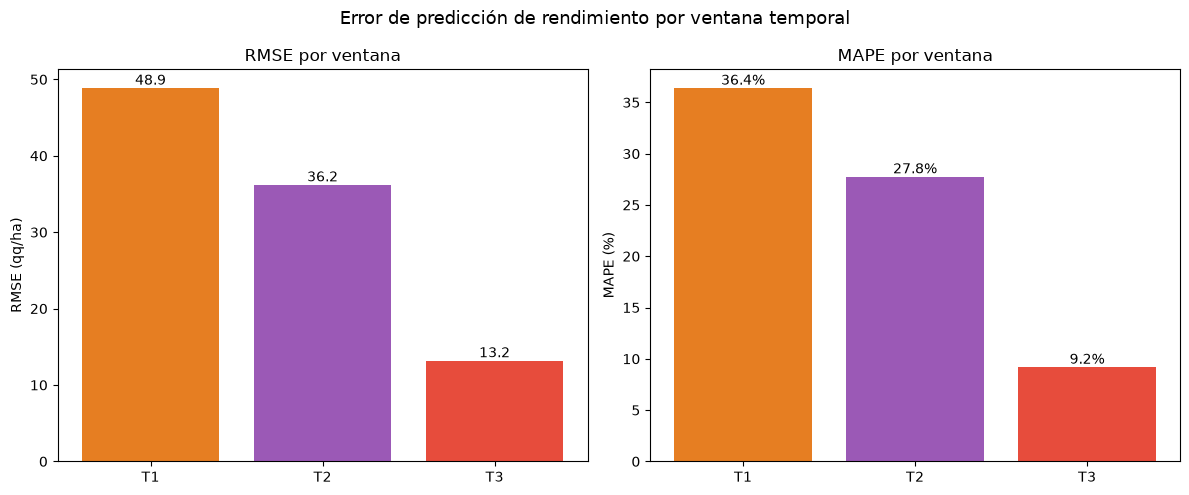

In [8]:
def graficar_barras_metricas(df_metricas):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ventanas = df_metricas.index.tolist()
    colores = ["#e67e22", "#9b59b6", "#e74c3c"]

    axes[0].bar(ventanas, df_metricas["rmse_qq_ha"], color=colores)
    axes[0].set_ylabel("RMSE (qq/ha)")
    axes[0].set_title("RMSE por ventana")
    for i, v in enumerate(df_metricas["rmse_qq_ha"]):
        axes[0].text(i, v, f"{v:.1f}", ha="center", va="bottom")

    axes[1].bar(ventanas, df_metricas["mape_pct"], color=colores)
    axes[1].set_ylabel("MAPE (%)")
    axes[1].set_title("MAPE por ventana")
    for i, v in enumerate(df_metricas["mape_pct"]):
        axes[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom")

    plt.suptitle("Error de predicción de rendimiento por ventana temporal", fontsize=13)
    plt.tight_layout()
    plt.savefig("barras_rmse_mape_por_ventana.pdf", format="pdf", bbox_inches="tight")
    plt.show()

graficar_barras_metricas(df_metricas)

## 8. Fan chart por parcela

Se conserva EOS aquí únicamente como punto de anclaje visual (coincide con el valor final por
diseño, ver sección 4), no como evidencia de precisión predictiva.

In [9]:
def graficar_fan_chart_parcela(df_conv):
    from ipywidgets import Dropdown, interact
    parcelas = sorted(df_conv["id_parcela"].unique())
    dropdown = Dropdown(options=parcelas, description="Parcela:")

    def _plot(pid):
        sub = df_conv[df_conv["id_parcela"] == pid].sort_values("id_ciclo")
        if sub.empty:
            print("Sin datos")
            return
        fig, ax = plt.subplots(figsize=(12, 5))
        ciclos = sub["id_ciclo"].astype(str).values
        x = np.arange(len(ciclos))
        ax.plot(x, sub["yield_final_qq_ha"].values, "ko-", linewidth=2, markersize=6, label="Final (real)")
        colores = {"T1": "#e67e22", "T2": "#9b59b6", "T3": "#e74c3c", "EOS": "#2ecc71"}
        for v in ["T1", "T2", "T3", "EOS"]:
            col_y = f"yield_{v.lower()}_qq_ha"
            vals = sub[col_y].values
            etiqueta = f"{v} (referencia, no predicción)" if v == "EOS" else v
            ax.plot(x, vals, "s--", color=colores[v], linewidth=1, markersize=4, alpha=0.7, label=etiqueta)
        ax.set_xticks(x)
        ax.set_xticklabels(ciclos, rotation=45, ha="right")
        ax.set_ylabel("Yield (qq/ha)")
        ax.set_title(f"Parcela {pid}")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    interact(_plot, pid=dropdown)

graficar_fan_chart_parcela(df_conv)

interactive(children=(Dropdown(description='Parcela:', options=(np.int64(0), np.int64(1), np.int64(2), np.int6…

Gráfica exportada exitosamente como: fan_chart_parcela_4.pdf


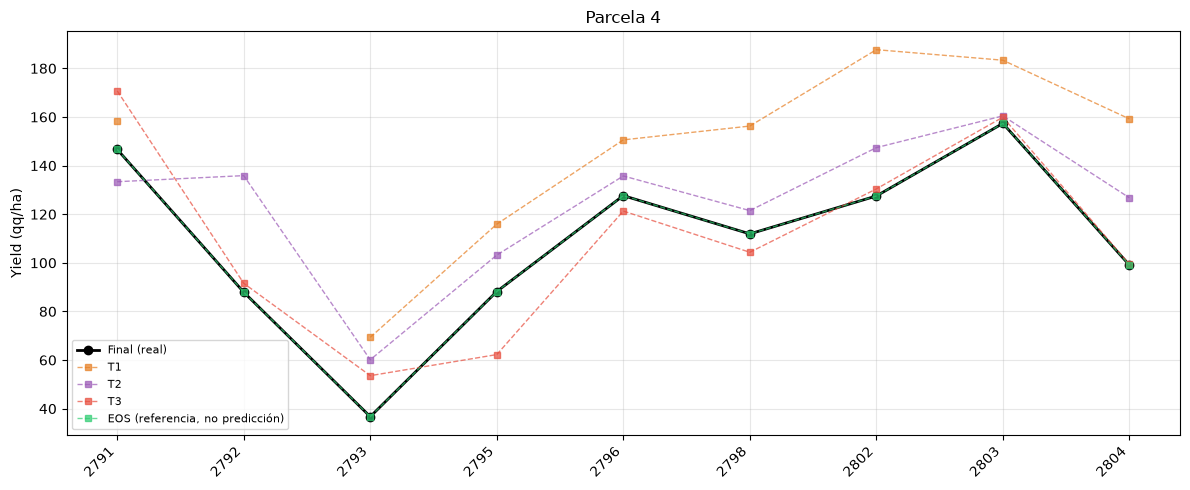

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def graficar_fan_chart_parcela_static(df_conv, pid):
    """
    Genera un fan chart estático para una parcela específica y lo exporta a PDF.
    
    Parámetros:
    - df_conv: DataFrame con los datos de convergencia.
    - pid: ID de la parcela a graficar.
    """
    # Filtrar y ordenar los datos para la parcela seleccionada
    sub = df_conv[df_conv["id_parcela"] == pid].sort_values("id_ciclo")
    
    if sub.empty:
        print(f"Sin datos para la parcela {pid}")
        return

    # Crear la figura
    fig, ax = plt.subplots(figsize=(12, 5))
    ciclos = sub["id_ciclo"].astype(str).values
    x = np.arange(len(ciclos))

    # Línea de rendimiento final (real)
    ax.plot(x, sub["yield_final_qq_ha"].values, "ko-", linewidth=2, markersize=6, label="Final (real)")

    # Líneas de las ventanas (T1, T2, T3, EOS)
    colores = {"T1": "#e67e22", "T2": "#9b59b6", "T3": "#e74c3c", "EOS": "#2ecc71"}
    for v in ["T1", "T2", "T3", "EOS"]:
        col_y = f"yield_{v.lower()}_qq_ha"
        
        # Verificamos que la columna exista en el DataFrame para evitar errores
        if col_y in sub.columns:
            vals = sub[col_y].values
            etiqueta = f"{v} (referencia, no predicción)" if v == "EOS" else v
            ax.plot(x, vals, "s--", color=colores[v], linewidth=1, markersize=4, alpha=0.7, label=etiqueta)

    # Configuración visual de la gráfica
    ax.set_xticks(x)
    ax.set_xticklabels(ciclos, rotation=45, ha="right")
    ax.set_ylabel("Yield (qq/ha)")
    ax.set_title(f"Parcela {pid}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Ajuste de diseño y exportación a PDF
    plt.tight_layout()
    
    nombre_archivo = f"fan_chart_parcela_{pid}.pdf"
    plt.savefig(nombre_archivo, format="pdf", bbox_inches="tight")
    
    print(f"Gráfica exportada exitosamente como: {nombre_archivo}")
    plt.show()
    plt.close(fig)

# --- Ejemplo de uso ---
# Suponiendo que tienes un ID de parcela específico, por ejemplo 10245:
graficar_fan_chart_parcela_static(df_conv, pid=4)

# Si quieres exportar las gráficas de varias parcelas a la vez, puedes usar un bucle:
# ids_a_exportar = [10245, 10246, 10247]
# for id_parcela in ids_a_exportar:
#     graficar_fan_chart_parcela_static(df_conv, pid=id_parcela)

## 9. Fan chart agregado

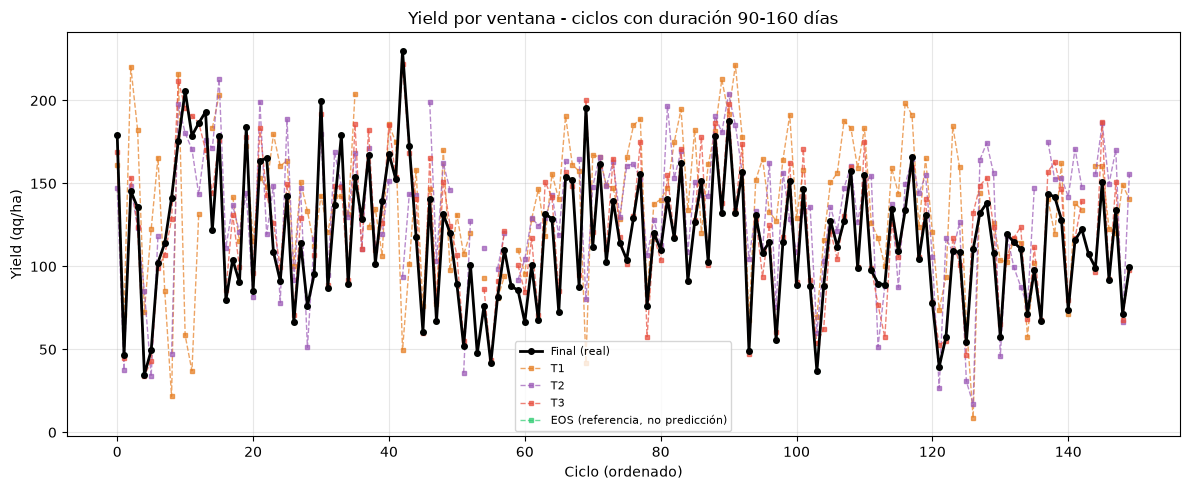

In [10]:
def graficar_fan_chart_agregado(df_conv):
    fig, ax = plt.subplots(figsize=(12, 5))
    df_plot = df_conv.sort_values("id_ciclo").copy()
    df_plot["order"] = range(len(df_plot))
    ax.plot(df_plot["order"], df_plot["yield_final_qq_ha"], "ko-", linewidth=2, markersize=4,
            label="Final (real)", zorder=5)
    colores = {"T1": "#e67e22", "T2": "#9b59b6", "T3": "#e74c3c", "EOS": "#2ecc71"}
    for v in ["T1", "T2", "T3", "EOS"]:
        col_y = f"yield_{v.lower()}_qq_ha"
        vals = df_plot[col_y].values
        etiqueta = f"{v} (referencia, no predicción)" if v == "EOS" else v
        ax.plot(df_plot["order"], vals, "s--", color=colores[v], linewidth=1, markersize=3,
                alpha=0.7, label=etiqueta)
    ax.set_xlabel("Ciclo (ordenado)")
    ax.set_ylabel("Yield (qq/ha)")
    ax.set_title(f"Yield por ventana - ciclos con duración {DURACION_MIN_DIAS}-{DURACION_MAX_DIAS} días")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("fan_chart_agregado.pdf", format="pdf", bbox_inches="tight")
    plt.show()

graficar_fan_chart_agregado(df_conv)

## 10. Tablero resumen

In [11]:
def tablero_resumen(df_conv, df_metricas):
    print("=" * 60)
    print("RESUMEN DE PREDICCIONES (Pipeline - desde BD)")
    print("=" * 60)
    print(f"Filtro de duración aplicado: {DURACION_MIN_DIAS}-{DURACION_MAX_DIAS} días")
    print(f"Total ciclos evaluados: {len(df_conv)}")
    completos = df_conv.dropna(subset=["yield_t1_qq_ha", "yield_t2_qq_ha", "yield_t3_qq_ha"])
    print(f"Ciclos con T1, T2 y T3 disponibles: {len(completos)}")
    if "temporada" in df_conv.columns:
        temps = df_conv["temporada"].value_counts().to_dict()
        print(f"Temporadas: {temps}")
    print()
    print("--- Métricas de error (T1/T2/T3; EOS excluido por ser tautológico) ---")
    display(df_metricas.round(3))
    print()
    print("--- Top 10 errores absolutos (T3, ventana más avanzada evaluada) ---")
    top10 = df_conv.dropna(subset=["error_t3_qq_ha"]).reindex(
        df_conv["error_t3_qq_ha"].abs().sort_values(ascending=False).index
    ).head(10)
    display(top10[["id_ciclo", "id_parcela", "temporada", "duracion_dias",
                    "yield_final_qq_ha", "yield_t3_qq_ha", "error_t3_qq_ha", "error_pct_t3"]])
    print()
    print("--- Ciclos con mejor predicción T3 (error < 5%) ---")
    buenos = df_conv.dropna(subset=["error_pct_t3"]).copy()
    buenos = buenos[np.abs(buenos["error_pct_t3"]) < 5]
    print(f"Total: {len(buenos)}/{len(df_conv.dropna(subset=['error_pct_t3']))} "
          f"({len(buenos)/len(df_conv.dropna(subset=['error_pct_t3']))*100:.1f}%)")
    if not buenos.empty:
        display(buenos[["id_ciclo", "id_parcela", "temporada",
                         "yield_final_qq_ha", "yield_t3_qq_ha", "error_pct_t3"]].head())

tablero_resumen(df_conv, df_metricas)

RESUMEN DE PREDICCIONES (Pipeline - desde BD)
Filtro de duración aplicado: 90-160 días
Total ciclos evaluados: 150
Ciclos con T1, T2 y T3 disponibles: 133
Temporadas: {'postrera': 88, 'primera': 62}

--- Métricas de error (T1/T2/T3; EOS excluido por ser tautológico) ---


,n,rmse_qq_ha,mae_qq_ha,mape_pct,bias_qq_ha,bias_pct,r2,r2_pearson_al_cuadrado
ventana,,,,,,,,
T1,140,48.873,38.303,36.402,18.540,24.361,-0.576,0.141
T2,140,36.218,28.538,27.761,12.990,15.637,0.143,0.408
T3,145,13.198,10.284,9.196,4.747,4.343,0.889,0.913



--- Top 10 errores absolutos (T3, ventana más avanzada evaluada) ---


,id_ciclo,id_parcela,temporada,duracion_dias,yield_final_qq_ha,yield_t3_qq_ha,error_t3_qq_ha,error_pct_t3
43,2864.0,9.0,primera,126.0,151.150851,187.288254,36.137404,23.908171
32,2630.0,1.0,primera,104.0,175.836748,211.676195,35.839447,20.382228
40,2675.0,12.0,primera,134.0,153.914884,185.686560,31.771676,20.642367
42,2810.0,5.0,primera,148.0,88.995789,57.249665,-31.746124,-35.671490
10,2672.0,12.0,primera,141.0,179.114481,148.070402,-31.044079,-17.331976
88,2651.0,10.0,primera,103.0,104.041217,130.997725,26.956508,25.909450
123,2771.0,22.0,primera,104.0,151.382655,178.059339,26.676683,17.622021
44,2795.0,4.0,primera,146.0,88.203853,62.256521,-25.947332,-29.417459
118,2750.0,18.0,primera,114.0,139.686710,164.951245,25.264534,18.086570
0,2693.0,14.0,postrera,93.0,140.441881,165.028729,24.586847,17.506777



--- Ciclos con mejor predicción T3 (error < 5%) ---
Total: 55/145 (37.9%)


,id_ciclo,id_parcela,temporada,yield_final_qq_ha,yield_t3_qq_ha,error_pct_t3
12,2860,9,primera,99.226761,96.525477,-2.722335
17,2792,4,postrera,87.922483,91.573026,4.152003
18,2806,5,postrera,97.540064,99.199314,1.701096
19,2820,6,postrera,78.097056,78.620359,0.670068
20,2684,13,postrera,152.598604,154.099321,0.983441
